<a href="https://colab.research.google.com/github/Allanlin001/CatUnet/blob/main/Animal_UNET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
%pylab inline
#Magic command specfic to IPython environments like Google Collab or Jupyter
# %pylab imports numpy and matplotlib and inline allows the plot to be shown directly in the notebook instead of another tab

Populating the interactive namespace from numpy and matplotlib


In [2]:
!pip install keras-unet

In [18]:
from keras_unet.models import custom_unet
#allows easy access to prebuilt u-net model

In [19]:
#Upload Folders and Files from Google Drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
import numpy as np
from PIL import Image
import os

# Define the path to your specific folder (already defined in 'my_folder_path')
image_folder_path = '/content/drive/MyDrive/Birman(Cat Images)'

preprocessed_images_list = []

# List all files in the directory
for filename in os.listdir(image_folder_path):
    # Check if the file is an image
    if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        image_path = os.path.join(image_folder_path, filename)
        try:
            img = Image.open(image_path)
            # Convert to grayscale, faster for computing
            img_gray = img.convert('L') # 'L' mode for grayscale
            # Resize to the model's expected input size
            img_resized = img_gray.resize((320, 320))
            # Convert to NumPy array
            img_array = np.array(img_resized)
            # Add channel dimension and normalize to [0, 1]
            # UNet expects input_shape=(batch_size, height, width, channels)
            img_preprocessed = img_array[np.newaxis, ..., np.newaxis] / 255.0
            preprocessed_images_list.append(img_preprocessed)
        except Exception as e:
            print(f"Could not process {filename}: {e}")

if preprocessed_images_list:
    # Concatenate all preprocessed images into a single NumPy array
    # The resulting shape will be (num_images, 320, 320, 1)
    all_images = np.concatenate(preprocessed_images_list, axis=0)
    print(f"Successfully loaded and preprocessed {len(preprocessed_images_list)} images.")
    print(f"Combined images array shape: {all_images.shape}")
else:
    print(f"No image files found or processed in {image_folder_path}")
    all_images = np.array([]) # Ensure 'all_images' is defined even if empty


Successfully loaded and preprocessed 200 images.
Combined images array shape: (200, 320, 320, 1)


In [24]:

if not isinstance(images, np.ndarray):
    # Re-loading the image to ensure 'images' is a NumPy array
    img = Image.open(image_path)
    images = np.array(img)

# Define the output path for the NPZ file
output_npz_path = '/content/drive/MyDrive/Birman(Cat Images)/Birman_1_converted.npz'

# Save the 'images' NumPy array into an NPZ file
# You can save multiple arrays in an NPZ file by providing keyword arguments.
# Here, we'll save it under the key 'image_data'.
np.savez_compressed(output_npz_path, image_data=images)

print(f"Image successfully converted and saved to: {output_npz_path}")

Image successfully converted and saved to: /content/drive/MyDrive/Birman(Cat Images)/Birman_1_converted.npz


In [32]:

# Check if all_images were successfully loaded
if all_images.size == 0:
    print("No images were loaded. Please check the folder path and image files.")
    # Create a dummy dataset to prevent errors, or raise an error
    # For now, let's create a minimal dummy set so the notebook can proceed
    dummy_shape = (1, 320, 320, 1)
    X_data = np.random.rand(*dummy_shape).astype(np.float32)
    # For image generation (autoencoder style), y_data is the same as X_data
    y_data = X_data.copy()
    print("Using dummy data for X_data and y_data.")
else:
    X_data = all_images
    # For image generation (autoencoder style), y_data is the same as X_data
    y_data = all_images.copy()
    num_images = X_data.shape[0]


# Split into train and test sets
if num_images >= 2:
    split_idx = num_images - 3
    X_train = X_data[:split_idx]
    y_train = y_data[:split_idx]
    X_test = X_data[split_idx:]
    y_test = y_data[split_idx:]
elif num_images == 1:
    X_train = X_data
    y_train = y_data
    X_test = X_data # Use the same image for test for demonstration
    y_test = y_data # Use the same image for test for demonstration
else:
    # Fallback if no images were processed (should be handled by the 'all_images.size == 0' block)
    X_train = X_data
    y_train = y_data
    X_test = X_data
    y_test = y_data

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")


X_train shape: (197, 320, 320, 1), y_train shape: (197, 320, 320, 1)
X_test shape: (3, 320, 320, 1), y_test shape: (3, 320, 320, 1)


In [33]:
from keras_unet.models import custom_unet
from tensorflow.keras.callbacks import EarlyStopping

# 2. NETWORK
#
model = custom_unet(
    input_shape=(320, 320, 1)
)
# Change loss function for image reconstruction
model.compile(loss='mean_squared_error')


In [34]:

# 3. TRAIN

#Implements early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train, y_train, validation_split=0.1, epochs=50, callbacks=[early_stopping])


Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 38s 5s/step - loss: 0.0378 - val_loss: 0.0682
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.0143 - val_loss: 0.0738
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.0105 - val_loss: 0.0793
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.0072 - val_loss: 0.0786
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.0067 - val_loss: 0.0754
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.0053 - val_loss: 0.0713
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.0050 - val_loss: 0.0628
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.0050 - val_loss: 0.0577
Epoch 9/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0055 - val_loss: 0.0512
Epoch 10/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.0048 - val_loss: 0.0462
Epoch 11/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.0050 - val_loss: 0.0414
Epoch 12/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 0.0037 - val_loss: 0.0372
Ep

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


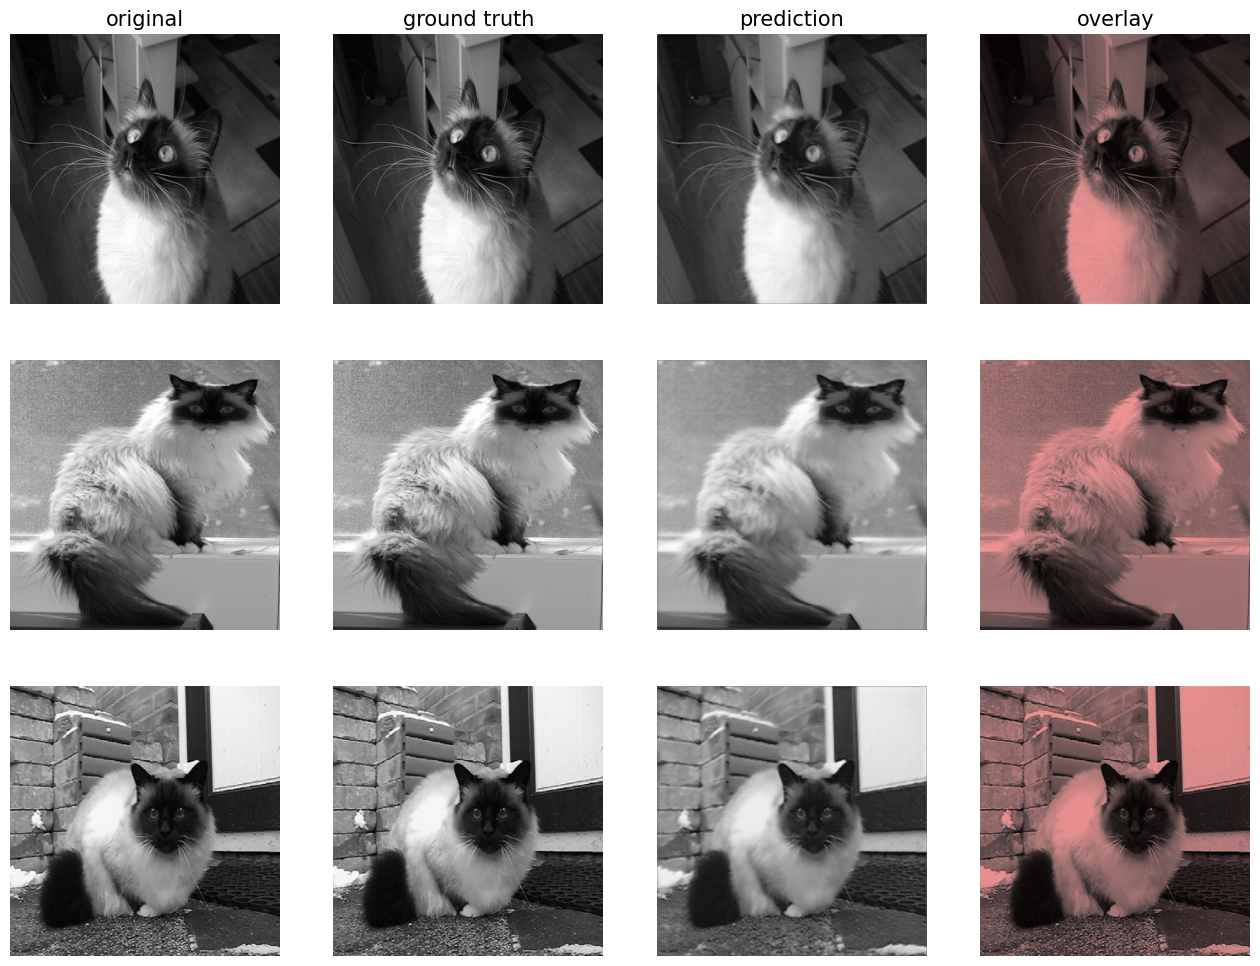

In [35]:
from keras_unet.utils import plot_imgs

# predict/ Ensure y_pred is generated before plotting
y_pred = model.predict(X_test)

# For image generation, mask_imgs should be the original images (X_test) for comparison
plot_imgs(org_imgs=X_test, mask_imgs=X_test, pred_imgs=y_pred, nm_img_to_plot=5)
